In [1]:
import pandas as pd
from pathlib import Path

from build_utils import (
    get_universalization_summary,
    get_outcome_metrics,
    get_experimental_data,
    build_design_matrix,
)


In [2]:
# Which experimental data to use
XP_FILE = "country_agg_judgment.csv"  # or your Brazil file, etc.
COUNTRY = None                                # pool over all countries (or select only one)

xp = get_experimental_data(XP_FILE)  # participant data
out = get_outcome_metrics(recompute=False) # outcome metrics 

In [12]:
import pandas as pd
import statsmodels.api as sm

def make_aw_corr_grid(
    xp_df,
    out_df,
    runs,                  # dict: tag -> run_label
    country=None,
    meta=None,             # optional dict: tag -> {info, order, reasoning}
    recompute_univ=False,
):
    """
    Build a correlation grid between participants and model U_AW (univ_aggregate_welfare).

    Parameters
    ----------
    xp_df : DataFrame
        Experimental data with columns ['stimulus', 'judgment_mean', ...].
    out_df : DataFrame
        Outcome metrics from get_outcome_metrics().
    runs : dict
        Mapping of model tags to run_label directories, e.g.
        {"joe": "joe", "random": "full_random", ...}
    country : str or None
        Passed through to build_design_matrix (to restrict to a country).
    meta : dict or None
        Optional per-model metadata, e.g.
        {
          "participants": {"info": None, "order": None, "reasoning": None},
          "joe":          {"info": "full", "order": "fixed",  "reasoning": "L0"},
          "random":       {"info": "full", "order": "random", "reasoning": "L0"},
          ...
        }
        If None or missing keys, fields default to None.
    recompute_univ : bool
        If True, forces recomputation of universalization summaries from raw sim files.

    Returns
    -------
    grid_df : DataFrame
        Correlation grid with columns: tag, info, order, reasoning, corr_with_*.
    styled : Styler
        Pandas Styler with colored correlation cells.
    """
    # 1) Build universalization summaries and design matrices
    univ_summaries = {}
    design_mats = {}

    for tag, run_label in runs.items():
        univ = get_universalization_summary(run_label, recompute=recompute_univ)
        univ_summaries[tag] = univ

        design = build_design_matrix(
            univ_df=univ,
            out_df=out_df,
            xp_df=xp_df,
            country=country,
        )
        design_mats[tag] = design

    # 2) Build combined df: participants + U_AW per model
    base = (
        xp_df[["stimulus", "judgment_mean"]]
        .drop_duplicates(subset=["stimulus"])
        .copy()
    )
    combined = base.copy()

    for tag, design in design_mats.items():
        sub = design[["stimulus", "univ_aggregate_welfare"]].copy()
        sub = sub.rename(columns={"univ_aggregate_welfare": f"U_AW_{tag}"})
        combined = combined.merge(sub, on="stimulus", how="inner")

    # 3) Correlation matrix
    cols_for_corr = ["judgment_mean"] + [
        c for c in combined.columns if c.startswith("U_AW_")
    ]
    corr_mat = combined[cols_for_corr].corr(method="pearson")

    # 4) Build grid with meta + correlations
    tags = ["participants"] + list(runs.keys())

    # mapping tags -> column names in corr_mat
    corr_key = {"participants": "judgment_mean"}
    corr_key.update({tag: f"U_AW_{tag}" for tag in runs.keys()})

    # default metadata if not provided
    meta = meta or {}
    for tag in tags:
        if tag not in meta:
            meta[tag] = {"info": None, "order": None, "reasoning": None}

    rows = []
    for row_tag in tags:
        row = {
            "tag": row_tag,
            "info": meta[row_tag].get("info"),
            "order": meta[row_tag].get("order"),
            "reasoning": meta[row_tag].get("reasoning"),
        }
        for col_tag in tags:
            col_name = f"corr_with_{col_tag}"
            if row_tag == col_tag:
                row[col_name] = None
            else:
                row_key = corr_key[row_tag]
                col_key = corr_key[col_tag]
                row[col_name] = corr_mat.loc[row_key, col_key]
        rows.append(row)

    grid_df = pd.DataFrame(rows)

    # 5) Rounded + styled version
    grid_rounded = grid_df.copy()
    corr_cols = [c for c in grid_rounded.columns if c.startswith("corr_with_")]
    for c in corr_cols:
        grid_rounded[c] = grid_rounded[c].round(3)

    styled = (
        grid_rounded
        .style
        .background_gradient(
            subset=corr_cols,
            cmap="RdBu_r",
            vmin=-1,
            vmax=1,
        )
        .format({c: "{:.2f}" for c in corr_cols}, na_rep="")
    )

    return grid_rounded, styled

def make_model_corr_grid(
    runs,                # dict: tag -> run_label
    metric="mean",       # e.g. "mean", "last", "first", "prop_finished"
    meta=None,
    recompute_univ=False,
):
    """
    Build a correlation grid between models for a given simulation metric
    (e.g. mean completion time, last completion time).
    
    Parameters
    ----------
    runs : dict
        Mapping of model tags to run_label directories.
    metric : str
        Column name in the universalization summary to use
        (e.g. "mean", "last", "first", "prop_finished").
    meta : dict or None
        Optional per-model metadata {tag: {info, order, reasoning}}.
    recompute_univ : bool
        If True, forces recomputation of universalization summaries.

    Returns
    -------
    grid_df : DataFrame
        Correlation grid with tag, info, order, reasoning, corr_with_*.
    styled : Styler
        Pandas Styler with colored correlation cells.
    """
    # 1) Universalization summaries per model
    univ_summaries = {}
    for tag, run_label in runs.items():
        univ = get_universalization_summary(run_label, recompute=recompute_univ)
        univ_summaries[tag] = univ

    # 2) Combined dataframe: map + metric_<tag> for each model
    tags = list(runs.keys())
    first_tag = tags[0]

    combined = univ_summaries[first_tag][["map", metric]].rename(
        columns={metric: f"{metric}_{first_tag}"}
    )

    for tag in tags[1:]:
        sub = univ_summaries[tag][["map", metric]].rename(
            columns={metric: f"{metric}_{tag}"}
        )
        combined = combined.merge(sub, on="map", how="inner")

    # 3) Correlations
    cols_for_corr = [c for c in combined.columns if c.startswith(f"{metric}_")]
    corr_mat = combined[cols_for_corr].corr(method="pearson")

    # mapping tag -> correlation matrix column
    corr_key = {tag: f"{metric}_{tag}" for tag in tags}

    # default metadata
    meta = meta or {}
    for tag in tags:
        if tag not in meta:
            meta[tag] = {"info": None, "order": None, "reasoning": None}

    # 4) Build grid
    rows = []
    for row_tag in tags:
        row = {
            "tag": row_tag,
            "info": meta[row_tag].get("info"),
            "order": meta[row_tag].get("order"),
            "reasoning": meta[row_tag].get("reasoning"),
        }
        for col_tag in tags:
            col_name = f"corr_with_{col_tag}"
            if row_tag == col_tag:
                row[col_name] = None
            else:
                row_key = corr_key[row_tag]
                col_key = corr_key[col_tag]
                row[col_name] = corr_mat.loc[row_key, col_key]
        rows.append(row)

    grid_df = pd.DataFrame(rows)

    # 5) Rounded + styled
    grid_rounded = grid_df.copy()
    corr_cols = [c for c in grid_rounded.columns if c.startswith("corr_with_")]
    for c in corr_cols:
        grid_rounded[c] = grid_rounded[c].round(3)

    styled = (
        grid_rounded
        .style
        .background_gradient(
            subset=corr_cols,
            cmap="RdBu_r",
            vmin=-1,
            vmax=1,
        )
        .format({c: "{:.2f}" for c in corr_cols}, na_rep="")
    )

    return grid_rounded, styled

In [13]:
RUNS = {
    # tag: run_label directory under ../data/simulations
    "joe": "joe_1_02-06",
    "random": "full_random_02-06",
    "random_blind": "blind_L0_random_02-06",
    "random_blind_L1": "blind_l1_random_02-06",
    "joe_new": "joe_03-02",
    "random_new": "random_03-02",
    "random_blind_new": "random_blind_03-02",
    "random_blind_L1_new": "random_blind_L1_03-02",
    "joe_reverted": "joe_reverted_03-03",
    "random_blind_reverted": "random_blind_reverted_03-03",
    "random_blind_L1_reverted": "random_blind_L1_reverted_03-03",
    "00full": "0full_03-04",
    "10full": "10full_03-04",
    "20full": "20full_03-04",    
    "30full": "30full_03-04",
    "40full": "40full_03-04",
    #"50full": "50full_03-04",
    "60full": "60full_03-04",
    "70full": "70full_03-04",    
    "80full": "80full_03-04",
    "90full": "90full_03-04",
}

meta = {
    "participants":      {"info": None,     "order": None,    "reasoning": None},
    "joe":               {"info": "full",   "order": "fixed", "reasoning": "L0"},
    "random":            {"info": "full",   "order": "random","reasoning": "L0"},
    "random_blind":   {"info": "blind",  "order": "random","reasoning": "L0"},
    "random_blind_L1":   {"info": "blind",  "order": "random","reasoning": "L1"},
        "joe_new":               {"info": "full",   "order": "fixed", "reasoning": "L0"},
    "random_new":            {"info": "full",   "order": "random","reasoning": "L0"},
    "random_blind_new":   {"info": "blind",  "order": "random","reasoning": "L0"},
    "random_blind_L1_new":   {"info": "blind",  "order": "random","reasoning": "L1"},
    "joe_reverted":               {"info": "full",   "order": "fixed", "reasoning": "L0"},
    "random_blind_reverted":   {"info": "blind",  "order": "random","reasoning": "L0"},
    "random_blind_L1_reverted":   {"info": "blind",  "order": "random","reasoning": "L1"},
    "random_blind_reverted":   {"info": "blind",  "order": "random","reasoning": "L0"},
    "00full":   {"info": .00,  "order": "random","reasoning": "L0"},
    "10full":   {"info": .10,  "order": "random","reasoning": "L0"},
    "20full":   {"info": .20,  "order": "random","reasoning": "L0"},
    "30full":   {"info": .30,  "order": "random","reasoning": "L0"},
    "40full":   {"info": .40,  "order": "random","reasoning": "L0"},
    #"50full":   {"info": .50,  "order": "random","reasoning": "L0"},
    "60full":   {"info": .60,  "order": "random","reasoning": "L0"},
    "70full":   {"info": .70,  "order": "random","reasoning": "L0"},
    "80full":   {"info": .80,  "order": "random","reasoning": "L0"},
    "90full":   {"info": .90,  "order": "random","reasoning": "L0"},
}

aw_grid, aw_styled = make_aw_corr_grid(
    xp_df=xp,
    out_df=out,
    runs=RUNS,
    country=COUNTRY,
    meta=meta,
    recompute_univ=False, #reset to true each time a new simulation is included
)

aw_grid  # bare numbers
aw_styled  # pretty colored table in notebook

,tag,info,order,reasoning,corr_with_participants,corr_with_joe,corr_with_random,corr_with_random_blind,corr_with_random_blind_L1,corr_with_joe_new,corr_with_random_new,corr_with_random_blind_new,corr_with_random_blind_L1_new,corr_with_joe_reverted,corr_with_random_blind_reverted,corr_with_random_blind_L1_reverted,corr_with_00full,corr_with_10full,corr_with_20full,corr_with_30full,corr_with_40full,corr_with_60full,corr_with_70full,corr_with_80full,corr_with_90full
0,participants,,,,,0.42,0.49,0.15,0.47,0.31,0.38,0.16,0.34,0.42,0.15,0.47,0.34,0.50,0.48,0.49,0.49,0.50,0.50,0.49,0.45
1,joe,full,fixed,L0,0.42,,0.99,0.58,0.98,0.83,0.86,0.29,0.86,1.00,0.58,0.98,0.62,0.97,0.98,0.98,0.99,0.96,0.98,0.97,0.99
2,random,full,random,L0,0.49,0.99,,0.61,0.99,0.84,0.88,0.37,0.87,0.99,0.61,0.99,0.66,0.99,0.99,0.99,0.99,0.99,1.00,0.99,0.99
3,random_blind,blind,random,L0,0.15,0.58,0.61,,0.60,0.54,0.61,0.56,0.61,0.58,1.00,0.60,0.54,0.65,0.63,0.65,0.61,0.67,0.63,0.65,0.58
4,random_blind_L1,blind,random,L1,0.47,0.98,0.99,0.60,,0.83,0.87,0.34,0.86,0.98,0.60,1.00,0.65,0.99,0.99,0.99,0.99,0.98,0.99,0.99,0.99
5,joe_new,full,fixed,L0,0.31,0.83,0.84,0.54,0.83,,0.99,0.40,0.99,0.83,0.54,0.83,0.54,0.81,0.82,0.82,0.82,0.81,0.83,0.83,0.83
6,random_new,full,random,L0,0.38,0.86,0.88,0.61,0.87,0.99,,0.44,0.99,0.86,0.61,0.87,0.58,0.86,0.87,0.88,0.87,0.87,0.88,0.88,0.86
7,random_blind_new,blind,random,L0,0.16,0.29,0.37,0.56,0.34,0.40,0.44,,0.42,0.29,0.56,0.34,0.64,0.41,0.38,0.37,0.36,0.39,0.38,0.39,0.36
8,random_blind_L1_new,blind,random,L1,0.34,0.86,0.87,0.61,0.86,0.99,0.99,0.42,,0.86,0.61,0.86,0.55,0.85,0.86,0.86,0.86,0.86,0.87,0.88,0.86
9,joe_reverted,full,fixed,L0,0.42,1.00,0.99,0.58,0.98,0.83,0.86,0.29,0.86,,0.58,0.98,0.62,0.97,0.98,0.98,0.99,0.96,0.98,0.97,0.99


In [14]:
aw_grid.to_csv("corr_grid_UAW.csv", index=False)

with open("corr_grid_UAW.html", "w") as f:
    f.write(aw_styled.to_html())

In [15]:
mean_grid, mean_styled = make_model_corr_grid(
    runs=RUNS,
    metric="mean",
    meta=meta,
    recompute_univ=False,
)

mean_styled = mean_styled.set_caption("Correlation grid — Mean completion time")
mean_styled

,tag,info,order,reasoning,corr_with_joe,corr_with_random,corr_with_random_blind,corr_with_random_blind_L1,corr_with_joe_new,corr_with_random_new,corr_with_random_blind_new,corr_with_random_blind_L1_new,corr_with_joe_reverted,corr_with_random_blind_reverted,corr_with_random_blind_L1_reverted,corr_with_00full,corr_with_10full,corr_with_20full,corr_with_30full,corr_with_40full,corr_with_60full,corr_with_70full,corr_with_80full,corr_with_90full
0,joe,full,fixed,L0,,0.99,0.74,0.99,0.99,0.98,0.54,0.98,1.00,0.74,0.99,0.78,0.98,0.99,0.99,0.99,0.98,0.99,0.98,1.00
1,random,full,random,L0,0.99,,0.77,1.00,0.99,0.99,0.61,0.99,0.99,0.77,1.00,0.81,1.00,1.00,1.00,1.00,0.99,1.00,0.99,1.00
2,random_blind,blind,random,L0,0.74,0.77,,0.76,0.77,0.81,0.71,0.80,0.74,1.00,0.76,0.73,0.79,0.78,0.79,0.77,0.81,0.78,0.80,0.75
3,random_blind_L1,blind,random,L1,0.99,1.00,0.76,,1.00,0.99,0.58,0.99,0.99,0.76,1.00,0.81,1.00,1.00,1.00,1.00,0.99,1.00,0.99,1.00
4,joe_new,full,fixed,L0,0.99,0.99,0.77,1.00,,0.99,0.57,1.00,0.99,0.77,1.00,0.79,0.99,0.99,0.99,0.99,0.99,0.99,1.00,0.99
5,random_new,full,random,L0,0.98,0.99,0.81,0.99,0.99,,0.61,1.00,0.98,0.81,0.99,0.81,0.99,0.99,0.99,0.99,0.99,0.99,1.00,0.98
6,random_blind_new,blind,random,L0,0.54,0.61,0.71,0.58,0.57,0.61,,0.60,0.54,0.71,0.58,0.79,0.64,0.61,0.61,0.60,0.63,0.61,0.62,0.58
7,random_blind_L1_new,blind,random,L1,0.98,0.99,0.80,0.99,1.00,1.00,0.60,,0.98,0.80,0.99,0.80,0.99,0.99,0.99,0.99,0.99,1.00,1.00,0.99
8,joe_reverted,full,fixed,L0,1.00,0.99,0.74,0.99,0.99,0.98,0.54,0.98,,0.74,0.99,0.78,0.98,0.99,0.99,0.99,0.98,0.99,0.98,1.00
9,random_blind_reverted,blind,random,L0,0.74,0.77,1.00,0.76,0.77,0.81,0.71,0.80,0.74,,0.76,0.73,0.79,0.78,0.79,0.77,0.81,0.78,0.80,0.75


In [16]:
last_grid, last_styled = make_model_corr_grid(
    runs=RUNS,
    metric="last",
    meta=meta,
    recompute_univ=False,
)

last_styled = last_styled.set_caption("Correlation grid — Last completion time")
last_styled

,tag,info,order,reasoning,corr_with_joe,corr_with_random,corr_with_random_blind,corr_with_random_blind_L1,corr_with_joe_new,corr_with_random_new,corr_with_random_blind_new,corr_with_random_blind_L1_new,corr_with_joe_reverted,corr_with_random_blind_reverted,corr_with_random_blind_L1_reverted,corr_with_00full,corr_with_10full,corr_with_20full,corr_with_30full,corr_with_40full,corr_with_60full,corr_with_70full,corr_with_80full,corr_with_90full
0,joe,full,fixed,L0,,0.99,0.63,1.00,0.99,0.98,0.49,0.99,1.00,0.63,1.00,0.65,0.99,0.99,0.99,1.00,0.99,0.99,0.99,0.99
1,random,full,random,L0,0.99,,0.65,0.99,0.99,0.99,0.55,0.99,0.99,0.65,0.99,0.69,0.99,0.99,1.00,0.99,0.99,1.00,0.99,0.99
2,random_blind,blind,random,L0,0.63,0.65,,0.63,0.65,0.68,0.79,0.67,0.63,1.00,0.63,0.66,0.68,0.66,0.67,0.62,0.67,0.65,0.67,0.63
3,random_blind_L1,blind,random,L1,1.00,0.99,0.63,,0.99,0.98,0.51,0.99,1.00,0.63,1.00,0.66,0.99,1.00,0.99,1.00,0.99,0.99,0.99,1.00
4,joe_new,full,fixed,L0,0.99,0.99,0.65,0.99,,0.99,0.53,1.00,0.99,0.65,0.99,0.68,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99
5,random_new,full,random,L0,0.98,0.99,0.68,0.98,0.99,,0.57,0.99,0.98,0.68,0.98,0.70,0.99,0.99,0.99,0.98,0.99,0.99,0.99,0.99
6,random_blind_new,blind,random,L0,0.49,0.55,0.79,0.51,0.53,0.57,,0.55,0.49,0.79,0.51,0.70,0.58,0.55,0.56,0.51,0.56,0.56,0.57,0.53
7,random_blind_L1_new,blind,random,L1,0.99,0.99,0.67,0.99,1.00,0.99,0.55,,0.99,0.67,0.99,0.68,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99
8,joe_reverted,full,fixed,L0,1.00,0.99,0.63,1.00,0.99,0.98,0.49,0.99,,0.63,1.00,0.65,0.99,0.99,0.99,1.00,0.99,0.99,0.99,0.99
9,random_blind_reverted,blind,random,L0,0.63,0.65,1.00,0.63,0.65,0.68,0.79,0.67,0.63,,0.63,0.66,0.68,0.66,0.67,0.62,0.67,0.65,0.67,0.63


In [17]:
with open("corr_grid_UAW.html", "w") as f:
    f.write(aw_styled.to_html())

with open("corr_grid_mean.html", "w") as f:
    f.write(mean_styled.to_html())

with open("corr_grid_last.html", "w") as f:
    f.write(last_styled.to_html())

In [22]:
import dataframe_image as dfi

aw_styled = aw_styled.set_caption("Correlation grid — Universalized Aggregate Welfare (U_AW)")

dfi.export(
    aw_styled,
    "corr_grid_UAW.png",
    table_conversion="matplotlib",  # <- key change
)
dfi.export(mean_styled, "corr_grid_mean.png", table_conversion="matplotlib")
dfi.export(last_styled, "corr_grid_last.png", table_conversion="matplotlib")

In [23]:
#feb 27

In [24]:
import pandas as pd
import statsmodels.api as sm

def evaluate_uaw_contribution(
    xp_df,
    out_df,
    runs,                       # dict: tag -> run_label
    country=None,
    baseline_cols=("aggregate_welfare", "ordinal_harm_blind", "inequality"),
    uaw_col="univ_aggregate_welfare",
    recompute_univ=False,
):
    """
    For each simulation run, compare:
      - baseline model: rating_mean ~ baseline_cols
      - extended model: rating_mean ~ baseline_cols + U_AW_run

    Returns a DataFrame with R2, ΔR2, BIC, ΔBIC, and the coefficient/p-value for U_AW.
    """
    # 1) Build design matrices for each run (like before)
    design_mats = {}
    for tag, run_label in runs.items():
        univ = get_universalization_summary(run_label, recompute=recompute_univ)
        design = build_design_matrix(
            univ_df=univ,
            out_df=out_df,
            xp_df=xp_df,
            country=country,
        )
        design_mats[tag] = design

    results = []

    for tag, design in design_mats.items():
        df = design.copy()

        # keep only rows where U_AW is defined
        df = df.dropna(subset=[uaw_col])

        y = df["rating_mean"]
        X_base = df[list(baseline_cols)]
        X_base = sm.add_constant(X_base)

        # baseline model
        base_model = sm.OLS(y, X_base).fit()

        # extended model with U_AW
        X_full = df[list(baseline_cols) + [uaw_col]]
        X_full = sm.add_constant(X_full)
        full_model = sm.OLS(y, X_full).fit()

        results.append({
            "tag": tag,
            "n": int(full_model.nobs),

            "R2_baseline": base_model.rsquared,
            "R2_full": full_model.rsquared,
            "delta_R2": full_model.rsquared - base_model.rsquared,

            "BIC_baseline": base_model.bic,
            "BIC_full": full_model.bic,
            "delta_BIC": full_model.bic - base_model.bic,  # negative = better with U_AW

            "beta_U_AW": full_model.params.get(uaw_col, float("nan")),
            "p_U_AW": full_model.pvalues.get(uaw_col, float("nan")),
        })

    res_df = pd.DataFrame(results)

    # sort by “best improvement” – you can flip this as you like
    res_df = res_df.sort_values(by="delta_R2", ascending=False).reset_index(drop=True)

    return res_df

In [26]:
# 02-27: contribution to stats model instead of Pearson's r

uaw_eval = evaluate_uaw_contribution(
    xp_df=xp,
    out_df=out,
    runs=RUNS,
    country=COUNTRY,        # or a specific country if you want
    recompute_univ=False,
)

uaw_eval

,tag,n,R2_baseline,R2_full,delta_R2,BIC_baseline,BIC_full,delta_BIC,beta_U_AW,p_U_AW
0,40full,39,0.625166,0.705535,0.080369,65.798054,60.049957,-5.748096,0.109823,0.004457
1,random_blind_L1_reverted,39,0.625166,0.704344,0.079179,65.798054,60.207367,-5.590687,0.109961,0.004802
2,random_blind_L1,39,0.625166,0.704344,0.079179,65.798054,60.207367,-5.590687,0.109961,0.004802
3,joe_reverted,39,0.625166,0.699100,0.073935,65.798054,60.893015,-4.905039,0.102199,0.006658
4,joe,39,0.625166,0.699100,0.073935,65.798054,60.893015,-4.905039,0.102199,0.006658
5,70full,39,0.625166,0.697894,0.072728,65.798054,61.049131,-4.748923,0.111669,0.007174
6,90full,39,0.625166,0.697309,0.072143,65.798054,61.124531,-4.673522,0.105197,0.007438
7,random,39,0.625166,0.696694,0.071528,65.798054,61.203658,-4.594396,0.105658,0.007725
8,20full,39,0.625166,0.696585,0.071419,65.798054,61.217677,-4.580377,0.104401,0.007778
9,30full,39,0.625166,0.696404,0.071238,65.798054,61.241012,-4.557041,0.105449,0.007865


In [10]:
cols = [
    "tag",
    "R2_baseline",
    "R2_full",
    "delta_R2",
    "beta_U_AW",
    "p_U_AW",
]

display_df = uaw_eval[cols].copy()

display_df = display_df.round({
    "R2_baseline": 3,
    "R2_full": 3,
    "delta_R2": 3,
    "beta_U_AW": 3,
    "p_U_AW": 3,
})

display_df

,tag,R2_baseline,R2_full,delta_R2,beta_U_AW,p_U_AW
0,40full,0.625,0.706,0.080,0.110,0.004
1,random_blind_L1_reverted,0.625,0.704,0.079,0.110,0.005
2,random_blind_L1,0.625,0.704,0.079,0.110,0.005
3,joe_reverted,0.625,0.699,0.074,0.102,0.007
4,joe,0.625,0.699,0.074,0.102,0.007
5,70full,0.625,0.698,0.073,0.112,0.007
6,90full,0.625,0.697,0.072,0.105,0.007
7,random,0.625,0.697,0.072,0.106,0.008
8,20full,0.625,0.697,0.071,0.104,0.008
9,30full,0.625,0.696,0.071,0.105,0.008


In [26]:
import pandas as pd

# 1) Rebuild universalization summaries & design matrices if needed
univ_summaries = {}
design_mats = {}

for tag, run_label in RUNS.items():
    univ = get_universalization_summary(run_label, recompute=False)
    univ_summaries[tag] = univ
    
    design = build_design_matrix(
        univ_df=univ,
        out_df=out,
        xp_df=xp,
        country=COUNTRY,
    )
    design_mats[tag] = design

# 2) Start from participants' judgments: stimulus + judgment_mean
base = (
    xp[["stimulus", "judgment_mean"]]
    .drop_duplicates(subset=["stimulus"])
    .copy()
)

# 3) Add one column per model: its univ_aggregate_welfare
combined = base.copy()

for tag, design in design_mats.items():
    sub = design[["stimulus", "univ_aggregate_welfare"]].copy()
    sub = sub.rename(columns={"univ_aggregate_welfare": f"U_AW_{tag}"})
    combined = combined.merge(sub, on="stimulus", how="inner")

combined.head()

,stimulus,judgment_mean,U_AW_joe,U_AW_random,U_AW_random_blind,U_AW_random_blind_L1
0,new_maybe_6_1cut,2.771429,-4.183333,-4.283333,-21.600000,-4.208333
1,new_maybe_3_badder,1.666667,0.172881,0.084746,-0.522034,0.061017
2,yesline_D_bad,2.088235,-1.436364,-1.427273,-3.245455,-1.368182
3,yesline_B_bad,2.117647,-1.981250,-1.956250,-2.465625,-2.159375
4,new_yes_8_1cut,2.432432,-5.389655,-4.658621,-5.948276,-4.403448


In [31]:
cols_for_corr = ["judgment_mean"] + [c for c in combined.columns if c.startswith("U_AW_")]
corr_mat = combined[cols_for_corr].corr(method="pearson")
corr_mat

,judgment_mean,U_AW_joe,U_AW_random,U_AW_random_blind,U_AW_random_blind_L1
judgment_mean,1.000000,0.418179,0.485840,0.155109,0.473208
U_AW_joe,0.418179,1.000000,0.985720,0.583528,0.985132
U_AW_random,0.485840,0.985720,1.000000,0.613301,0.994387
U_AW_random_blind,0.155109,0.583528,0.613301,1.000000,0.600600
U_AW_random_blind_L1,0.473208,0.985132,0.994387,0.600600,1.000000


In [35]:
# Row / column order in the final grid
tags = [
    "participants",
    "joe",
    "random",
    "random_blind",
    "random_blind_L1",
]

# Map tags to the column names used in corr_mat
corr_key = {
    "participants": "judgment_mean",
    "joe": "U_AW_joe",
    "random": "U_AW_random",
    "random_blind": "U_AW_random_blind",
    "random_blind_L1": "U_AW_random_blind_L1",
}

# Metadata for Info / Order / Reasoning
meta = {
    "participants": {"info": None,     "order": None,    "reasoning": None},
    "joe":          {"info": "full",   "order": "fixed", "reasoning": "L0"},
    "random":       {"info": "full",   "order": "random","reasoning": "L0"},
    "random_blind": {"info": "blind","order": "random","reasoning": "L0"},
    "random_blind_L1": {"info": "blind","order": "random","reasoning": "L1"},
}

# Build the grid
rows = []
for row_tag in tags:
    row = {
        "tag": row_tag,
        "info": meta[row_tag]["info"],
        "order": meta[row_tag]["order"],
        "reasoning": meta[row_tag]["reasoning"],
    }
    for col_tag in tags:
        col_name = f"{col_tag}"
        if row_tag == col_tag:
            row[col_name] = None  # or pd.NA
        else:
            row_key = corr_key[row_tag]
            col_key = corr_key[col_tag]
            row[col_name] = corr_mat.loc[row_key, col_key]
    rows.append(row)

comparison_grid = pd.DataFrame(rows)
comparison_grid

,tag,info,order,reasoning,corr_with_participants,corr_with_joe,corr_with_random,corr_with_random_blind,corr_with_random_blind_L1
0,participants,None,None,None,NaN,0.418179,0.485840,0.155109,0.473208
1,joe,full,fixed,L0,0.418179,NaN,0.985720,0.583528,0.985132
2,random,full,random,L0,0.485840,0.985720,NaN,0.613301,0.994387
3,random_blind,blind,random,L0,0.155109,0.583528,0.613301,NaN,0.600600
4,random_blind_L1,blind,random,L1,0.473208,0.985132,0.994387,0.600600,NaN


In [36]:
# Assuming comparison_grid already exists

# 1) Round correlation columns
comparison_grid_rounded = comparison_grid.copy()
for c in comparison_grid_rounded.columns:
    if c.startswith(""):
        comparison_grid_rounded[c] = comparison_grid_rounded[c].round(3)

# 2) Style with background colors
corr_cols = [c for c in comparison_grid_rounded.columns if c.startswith("")]

styled = (
    comparison_grid_rounded
    .style
    .background_gradient(
        subset=corr_cols,
        cmap="coolwarm",  # you can change this
        vmin=-1, vmax=1   # so colors are comparable across tables
    )
    .format({c: "{:.2f}" for c in corr_cols})
)

styled

,tag,info,order,reasoning,corr_with_participants,corr_with_joe,corr_with_random,corr_with_random_blind,corr_with_random_blind_L1
0,participants,None,None,None,nan,0.42,0.49,0.15,0.47
1,joe,full,fixed,L0,0.42,nan,0.99,0.58,0.98
2,random,full,random,L0,0.49,0.99,nan,0.61,0.99
3,random_blind,blind,random,L0,0.15,0.58,0.61,nan,0.60
4,random_blind_L1,blind,random,L1,0.47,0.98,0.99,0.60,nan


In [41]:
# metric name in the univ summary, and a prefix for columns
METRIC = "mean"   # or "last" or "first"

# Start from joe's maps as reference (they should all share the same map set)
combined_mech = univ_summaries["joe"][["map", METRIC]].rename(
    columns={METRIC: f"{METRIC}_joe"}
)

for tag in ["random", "random_blind", "random_blind_L1"]:
    sub = univ_summaries[tag][["map", METRIC]].rename(
        columns={METRIC: f"{METRIC}_{tag}"}
    )
    combined_mech = combined_mech.merge(sub, on="map", how="inner")

combined_mech.head()

,map,mean_joe,mean_random,mean_random_blind,mean_random_blind_L1
0,10esque,61.725,63.025,71.575,65.725
1,7esque,38.425,39.950,42.025,40.750
2,9esque,38.975,37.500,44.725,41.825
3,maybe_4,29.050,27.375,28.450,27.750
4,maybe_5,31.100,31.025,33.275,31.875


In [42]:

cols_for_corr_mech = [c for c in combined_mech.columns if c.startswith(f"{METRIC}_")]
corr_mech = combined_mech[cols_for_corr_mech].corr(method="pearson")
corr_mech

,mean_joe,mean_random,mean_random_blind,mean_random_blind_L1
mean_joe,1.000000,0.992610,0.739423,0.993644
mean_random,0.992610,1.000000,0.773983,0.998262
mean_random_blind,0.739423,0.773983,1.000000,0.763395
mean_random_blind_L1,0.993644,0.998262,0.763395,1.000000


In [46]:
tags_models = ["joe", "random", "random_blind", "random_blind_L1"]

corr_key_mech = {
    "joe": f"{METRIC}_joe",
    "random": f"{METRIC}_random",
    "random_blind": f"{METRIC}_random_blind",
    "random_blind_L1": f"{METRIC}_random_blind_L1",
}

rows_mech = []
for row_tag in tags_models:
    row = {
        "tag": row_tag,
        "info": meta[row_tag]["info"],
        "order": meta[row_tag]["order"],
        "reasoning": meta[row_tag]["reasoning"],
    }
    for col_tag in tags_models:
        col_name = f"corr_with_{col_tag}"
        if row_tag == col_tag:
            row[col_name] = None
        else:
            row_key = corr_key_mech[row_tag]
            col_key = corr_key_mech[col_tag]
            row[col_name] = corr_mech.loc[row_key, col_key]
    rows_mech.append(row)

comparison_grid_mech = pd.DataFrame(rows_mech)

# Pretty version
corr_cols_mech = [c for c in comparison_grid_mech.columns if c.startswith("corr_with_")]

comparison_grid_mech_rounded = comparison_grid_mech.copy()
for c in corr_cols_mech:
    comparison_grid_mech_rounded[c] = comparison_grid_mech_rounded[c].round(3)

comparison_grid_mech_rounded.style.background_gradient(
    subset=corr_cols_mech, cmap="coolwarm", vmin=-1, vmax=1
)

,tag,info,order,reasoning,corr_with_joe,corr_with_random,corr_with_random_blind,corr_with_random_blind_L1
0,joe,full,fixed,L0,nan,0.993000,0.739000,0.994000
1,random,full,random,L0,0.993000,nan,0.774000,0.998000
2,random_blind,blind,random,L0,0.739000,0.774000,nan,0.763000
3,random_blind_L1,blind,random,L1,0.994000,0.998000,0.763000,nan


In [53]:
comparison_grid_rounded = comparison_grid.copy()

corr_cols = [c for c in comparison_grid_rounded.columns if c.startswith("corr_with_")]

# round correlation values
for c in corr_cols:
    comparison_grid_rounded[c] = comparison_grid_rounded[c].round(3)

styled = (
    comparison_grid_rounded
    .style
    .background_gradient(
        subset=corr_cols,
        cmap="RdBu_r",
        vmin=-1, vmax=1
    )
    .format({c: "{:.2f}" for c in corr_cols}, na_rep="")  # ✅ blanks out NaNs
)

renamed = comparison_grid_rounded.copy()

new_names = {
    "corr_with_participants": "P",
    "corr_with_joe": "J",
    "corr_with_random": "R",
    "corr_with_random_blind": "BL0",
    "corr_with_random_blind_L1": "BL1",
}
renamed = renamed.rename(columns=new_names)

html_path = "corr_grid_UAW.html"
with open(html_path, "w") as f:
    f.write(styled_short.to_html())
print("Saved to", html_path)

KeyError: "['BL0'] not in index"

In [55]:
!pip install dataframe_image

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [56]:
import dataframe_image as dfi

dfi.export(
    styled,             # the Styler object
    "corr_grid_UAW.png"       # output filename
)

/Users/lie-panis/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Error: It looks like you are using Playwright Sync API inside the asyncio loop.
Please use the Async API instead.

In [15]:
import statsmodels.api as sm

# Store per-run universalization summaries and design matrices
univ_summaries = {}
design_mats = {}

for run_label, pretty_name in RUNS.items():
    print(f"Loading universalization summary for {pretty_name} ({run_label})")
    univ = get_universalization_summary(run_label, recompute=False)
    univ_summaries[pretty_name] = univ
    
    # Build design matrix: xp ratings + scenario outcome + universalization metrics for that run
    design = build_design_matrix(
        univ_df=univ,
        out_df=out,
        xp_df=xp,
        country=COUNTRY,
    )
    design_mats[pretty_name] = design

print("Done.")

Loading universalization summary for joe (joe_1_02-06)
Loading universalization summary for random (full_random_02-06)
Loading universalization summary for random_blind (blind_L0_random_02-06)
Loading universalization summary for random_blind_L1 (blind_l1_random_02-06)
Done.


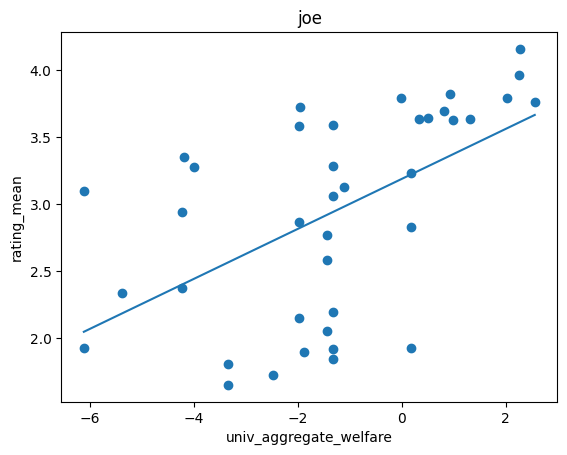

In [16]:
import matplotlib.pyplot as plt

run_to_plot = "joe"   # or any key from RUNS

dm = design_mats[run_to_plot].dropna(subset=["univ_aggregate_welfare", "judgment_mean"])
X = sm.add_constant(dm[["univ_aggregate_welfare"]])
y = dm["judgment_mean"]
model = sm.OLS(y, X).fit()

plt.scatter(dm["univ_aggregate_welfare"], dm["judgment_mean"])
x_vals = pd.Series(sorted(dm["univ_aggregate_welfare"]))
y_hat = model.params["const"] + model.params["univ_aggregate_welfare"] * x_vals
plt.plot(x_vals, y_hat)
plt.xlabel("univ_aggregate_welfare")
plt.ylabel("judgment_mean")
plt.title(run_to_plot)
plt.show()

In [17]:
mechanical_summary = []

for pretty_name, univ in univ_summaries.items():
    # These are per-map averages already; now average across maps
    row = {
        "run": pretty_name,
        "n_maps": len(univ),
        "mean_time_overall": univ["mean"].mean(),
        "first_time_overall": univ["first"].mean(),
        "last_time_overall": univ["last"].mean(),
        "prop_finished_overall": univ["prop_finished"].mean(),
    }
    mechanical_summary.append(row)

pd.DataFrame(mechanical_summary)

,run,n_maps,mean_time_overall,first_time_overall,last_time_overall,prop_finished_overall
0,joe,28,45.261607,22.471429,71.828571,1.000000
1,random,28,45.348214,22.135714,71.514286,1.000000
2,random_blind,28,58.351339,23.139286,99.251786,0.992857
3,random_blind_L1,28,46.229464,22.157143,73.942857,1.000000


In [18]:
PREDICTORS = [
    "univ_aggregate_welfare",
    "univ_inequality",
    "univ_cardinal_harm",
    "univ_ordinal_harm_blind",
    "univ_gini",
]

results_full = []

for pretty_name, design in design_mats.items():
    dm = design.dropna(subset=PREDICTORS + ["judgment_mean"])
    
    X = dm[PREDICTORS]
    X = sm.add_constant(X)
    y = dm["judgment_mean"]
    
    model = sm.OLS(y, X).fit()
    
    results_full.append({
        "run": pretty_name,
        "n_scenarios": len(dm),
        "r2": model.rsquared,
        "adj_r2": model.rsquared_adj,
        "aic": model.aic,
        "bic": model.bic,
    })

pd.DataFrame(results_full).sort_values("bic")

,run,n_scenarios,r2,adj_r2,aic,bic
1,random,39,0.541068,0.471533,71.038092,81.019462
3,random_blind_L1,39,0.521488,0.448986,72.667477,82.648847
0,joe,39,0.515871,0.442518,73.122637,83.104007
2,random_blind,39,0.289578,0.181939,88.079418,98.060787
